In [1]:
import os
import glob
from source.dataset import CombinedDataset
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pt_files = glob.glob(os.path.join("data/pt_std_p4-2/10002", "*.pt"))
targets = {"E_nu": [], "pT_nu": [], "eta_nu": [], "cos_phi_nu": [],
           "E_lep": [], "pT_lep": [], "eta_lep": [], "cos_phi_lep": [],
           "E_jet": [], "pT_jet": [], "eta_jet": [], "cos_phi_jet": [],
           "E_miss": [], "pT_miss": [], "eta_miss": [], "cos_phi_miss": [],}

In [3]:
dataloader = CombinedDataset(pt_files)

In [4]:
for event in tqdm(dataloader):
    for key in targets.keys():
        targets[key].append(event[key].item())
targets = {k: np.asarray(v) for k, v in targets.items()}

100%|██████████| 85927/85927 [00:02<00:00, 42512.10it/s]


In [5]:
print(targets["E_nu"])

[-0.93153936 -1.13780177 -0.58731198 ... -0.74248224  0.04515491
 -0.86989027]


In [6]:
# print(targets["p_lep"])

In [7]:


def plot_pairwise_2dhists(targets, bins=50, cmap="viridis"):
    keys = list(targets.keys())
    n = len(keys)

    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    
    # Convert to numpy arrays
    data = {k: np.asarray(v) for k, v in targets.items()}

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i < j:
                # Upper triangle: turn off
                ax.axis("off")
                continue

            x = data[keys[j]]
            y = data[keys[i]]

            if i == j:
                # Diagonal: 1D histogram
                ax.hist(x, bins=bins, histtype="stepfilled", alpha=0.7)
            else:
                # Lower triangle: 2D histogram
                h = ax.hist2d(x, y, bins=bins, cmap=cmap)

            # Labels only on outer axes
            if i == n - 1:
                ax.set_xlabel(f"Log10 {keys[j]}")
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(f"Log10 {keys[i]}")
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    return fig, axes

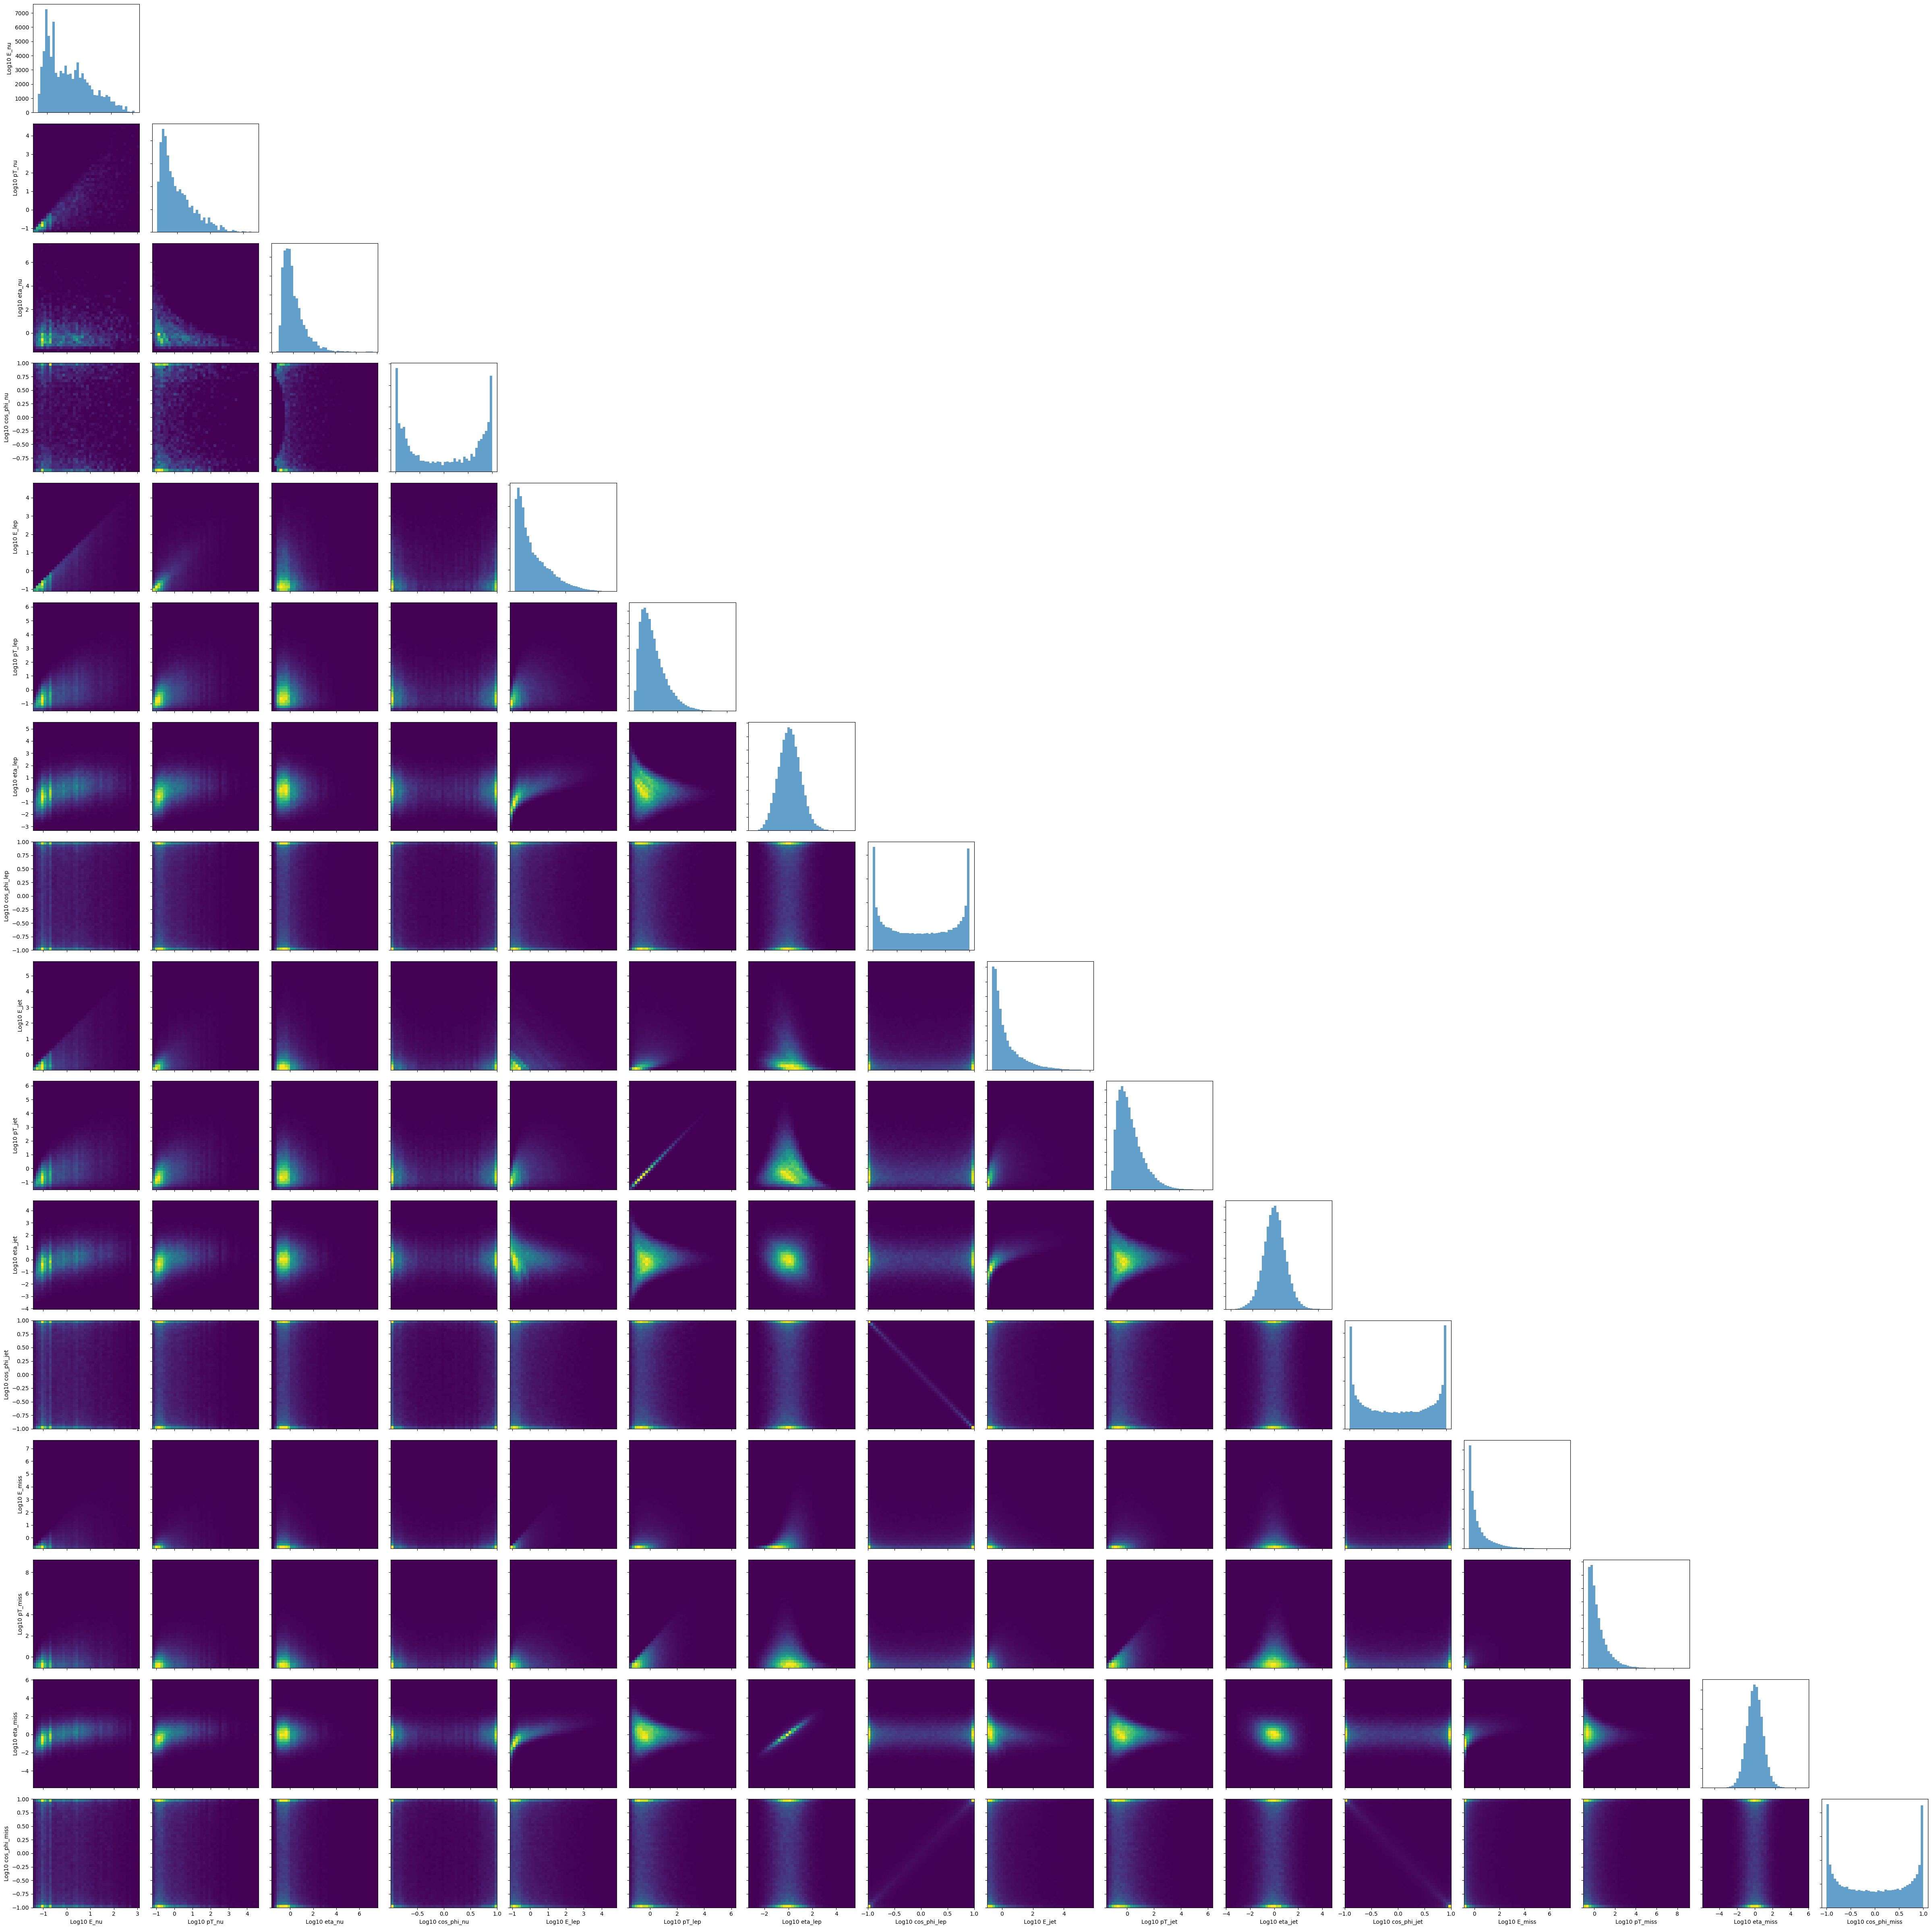

In [8]:
fig, axes = plot_pairwise_2dhists(targets, bins=40)
plt.show()

In [9]:
for var_name, values in targets.items():
    mean = np.mean(values)
    std = np.std(values)
    max_val = np.max(values)
    min_val = np.min(values)
    print(f"{var_name}:")
    print(f"\tmean: {mean:.3f}")
    print(f"\tstd: {std:.3f}")
    print(f"\tmax: {max_val:.3f}")
    print(f"\tmin: {min_val:.3f}")

E_nu:
	mean: 0.000
	std: 1.000
	max: 3.092
	min: -1.436
pT_nu:
	mean: 0.003
	std: 1.001
	max: 4.644
	min: -1.216
eta_nu:
	mean: 0.000
	std: 1.000
	max: 7.613
	min: -1.614
cos_phi_nu:
	mean: -0.009
	std: 0.760
	max: 1.000
	min: -1.000
E_lep:
	mean: -0.000
	std: 1.000
	max: 4.823
	min: -1.120
pT_lep:
	mean: -0.000
	std: 1.000
	max: 6.326
	min: -1.528
eta_lep:
	mean: 0.000
	std: 1.000
	max: 5.553
	min: -3.334
cos_phi_lep:
	mean: -0.001
	std: 0.706
	max: 1.000
	min: -1.000
E_jet:
	mean: 0.000
	std: 1.000
	max: 5.906
	min: -0.964
pT_jet:
	mean: 0.000
	std: 1.000
	max: 6.339
	min: -1.538
eta_jet:
	mean: -0.000
	std: 1.000
	max: 4.801
	min: -4.054
cos_phi_jet:
	mean: 0.001
	std: 0.706
	max: 1.000
	min: -1.000
E_miss:
	mean: 0.000
	std: 1.000
	max: 7.654
	min: -0.841
pT_miss:
	mean: 0.000
	std: 1.000
	max: 9.189
	min: -1.069
eta_miss:
	mean: 0.000
	std: 1.000
	max: 6.050
	min: -5.874
cos_phi_miss:
	mean: -0.000
	std: 0.706
	max: 1.000
	min: -1.000


In [10]:
E_diff = []
for i in range(len(targets["E_nu"])):
    E_diff.append(targets["E_nu"][i] - (targets["E_lep"][i] + targets["E_jet"][i]))

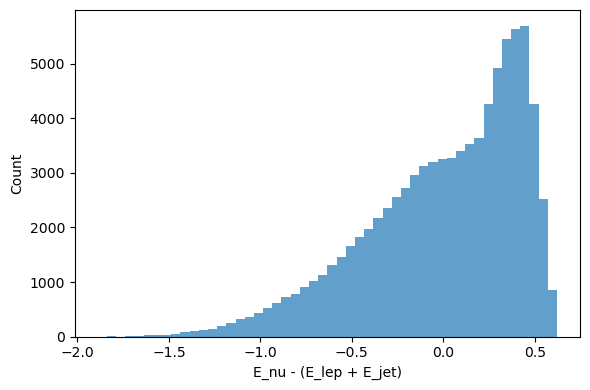

Mean E_diff: 0.000
Std E_diff: 0.422
Median E_diff: 0.088
Min E_diff: -1.889
Max E_diff: 0.622


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(E_diff, bins=50, histtype="stepfilled", alpha=0.7)
ax.set_xlabel("E_nu - (E_lep + E_jet)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean E_diff: {np.mean(E_diff):.3f}")
print(f"Std E_diff: {np.std(E_diff):.3f}")
print(f"Median E_diff: {np.median(E_diff):.3f}")
print(f"Min E_diff: {np.min(E_diff):.3f}")
print(f"Max E_diff: {np.max(E_diff):.3f}")

In [15]:
import yaml
from source.dataset import unnorm_data

config = yaml.safe_load(open("config/config.yaml"))

In [16]:
E_diff = []
for i in range(len(targets["E_nu"])):

    E_nu_unnormed = unnorm_data(targets["E_nu"][i], config["stats"]["E_nu"]["mean"], config["stats"]["E_nu"]["std"])
    E_lep_unnormed = unnorm_data(targets["E_lep"][i], config["stats"]["E_lep"]["mean"], config["stats"]["E_lep"]["std"])
    E_jet_unnormed = unnorm_data(targets["E_jet"][i], config["stats"]["E_jet"]["mean"], config["stats"]["E_jet"]["std"])
    E_miss_unnormed = unnorm_data(targets["E_miss"][i], config["stats"]["E_miss"]["mean"], config["stats"]["E_miss"]["std"])

    E_diff.append(E_nu_unnormed - (E_lep_unnormed + E_jet_unnormed))

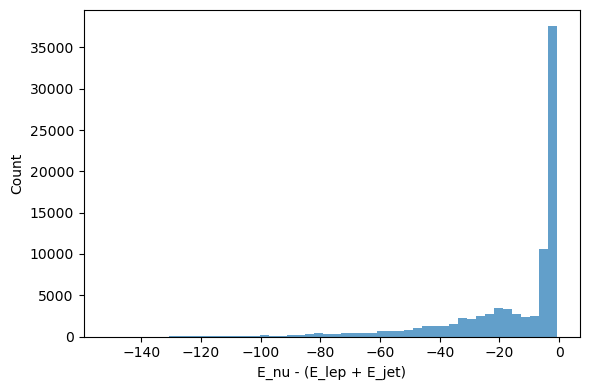

Mean E_diff: -15.773
Std E_diff: 21.033
Median E_diff: -3.906
Min E_diff: -151.756
Max E_diff: -0.577


In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(E_diff, bins=50, histtype="stepfilled", alpha=0.7)
ax.set_xlabel("E_nu - (E_lep + E_jet)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean E_diff: {np.mean(E_diff):.3f}")
print(f"Std E_diff: {np.std(E_diff):.3f}")
print(f"Median E_diff: {np.median(E_diff):.3f}")
print(f"Min E_diff: {np.min(E_diff):.3f}")
print(f"Max E_diff: {np.max(E_diff):.3f}")